/tmp/ipython-input-2499635746.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[mask, 'pot_kw'] = df.loc[mask, 'MdaPotenciaOutorgadaKw'].astype(object).apply(to_numeric_kW)
/tmp/ipython-input-2499635746.py:32: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['dat_entrada'] = pd.to_datetime(df['DatEntradaOperacao'], dayfirst=True, errors='coerce')
/tmp/ipython-input-2499635746.py:58: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  annual['renewable_share_annual'] = (annual['renewable_add

Período: 2000-2025
Total adicionado (kW): 140,315,568 kW
Total renovável adicionado (kW): 111,014,580 kW
Participação renovável cumulativa final: 79.12%

Regressão (participação cumulativa ~ ano):
                             OLS Regression Results                            
Dep. Variable:     renewable_share_cum   R-squared:                       0.754
Model:                             OLS   Adj. R-squared:                  0.744
Method:                  Least Squares   F-statistic:                     73.64
Date:                 Fri, 12 Sep 2025   Prob (F-statistic):           8.92e-09
Time:                         03:34:08   Log-Likelihood:                 38.592
No. Observations:                   26   AIC:                            -73.18
Df Residuals:                       24   BIC:                            -70.67
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
   

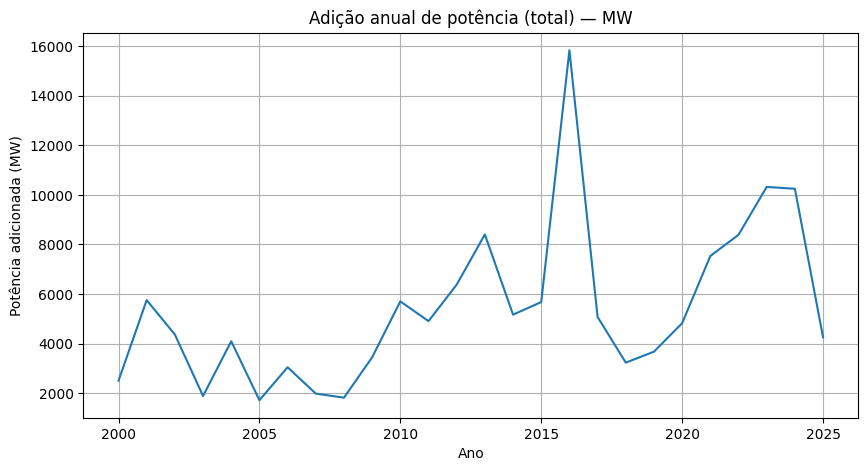

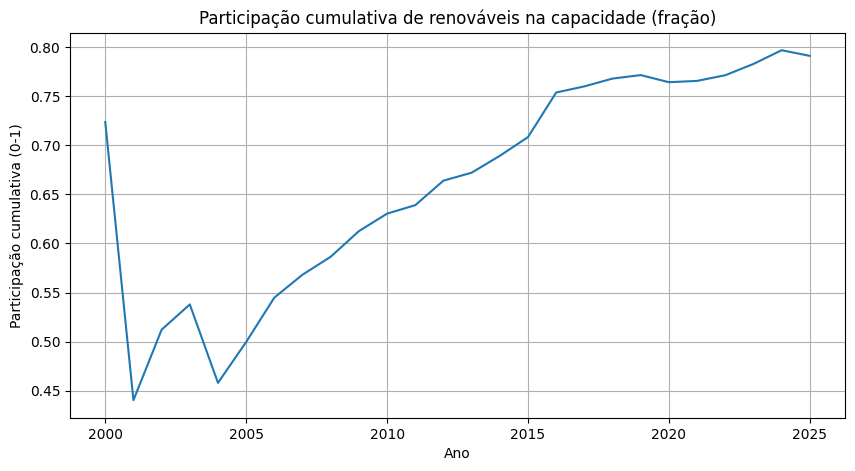

Agregação salva em: /content/annual_aggregation_renewables.csv


In [ ]:
# Coloque este bloco num notebook Colab e rode
# Requer: pandas, numpy, matplotlib, statsmodels, python-dateutil (geralmente já presentes no Colab)

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL

# 1) Ajuste o caminho do CSV para o arquivo que você enviou no Colab (faça upload via Files)
PATH = '/content/siga-empreendimentos-geracao (1).csv'  # ajuste conforme necessário

# 2) Leitura robusta (tenta detectar separador e usa latin-1 se houver acentuação)
df = pd.read_csv(PATH, engine='python', sep=None, encoding='latin-1')

# 3) Normalizações e conversões de potência (kW)
def to_numeric_kW(x):
    if pd.isna(x): return np.nan
    s = str(x).replace('.', '').replace(',', '.')
    s = re.sub(r'[^\d\.]', '', s)
    try:
        return float(s)
    except:
        return np.nan

df['pot_kw'] = df['MdaPotenciaFiscalizadaKw'].astype(object).apply(to_numeric_kW)
mask = df['pot_kw'].isna()
df.loc[mask, 'pot_kw'] = df.loc[mask, 'MdaPotenciaOutorgadaKw'].astype(object).apply(to_numeric_kW)

# 4) Datas: parse e filtrar a partir de 2000
df['dat_entrada'] = pd.to_datetime(df['DatEntradaOperacao'], dayfirst=True, errors='coerce')
df = df[df['dat_entrada'].notna()].copy()
df['year_entrada'] = df['dat_entrada'].dt.year
df = df[df['year_entrada'] >= 2000].copy()
df['year_entrada'] = df['year_entrada'].astype(int)

# 5) Classificação renovável (ajuste keywords conforme necessário)
df['origem_clean'] = df['DscOrigemCombustivel'].astype(str).str.strip()
renewable_origins = ['Hídrica','Eólica','Solar','Biomassa']
df['is_renewable'] = df['origem_clean'].isin(renewable_origins)
df['fonte_clean'] = df['DscFonteCombustivel'].astype(str).str.lower()
# busca por palavras em 'fonte' quando 'origem' não informar
df.loc[df['is_renewable'] == False, 'is_renewable'] = df.loc[df['is_renewable'] == False, 'fonte_clean'].str.contains(
    'hidrául|potencial hidráulico|eólica|vento|solar|biomassa|floresta|resíduos|agro|biocombust', na=False)

# 6) Agregação anual (kW)
annual = df.groupby('year_entrada').agg(
    total_added_kw = ('pot_kw', 'sum'),
    renewable_added_kw = ('pot_kw', lambda x: x[df.loc[x.index, 'is_renewable']].sum())
).reset_index().set_index('year_entrada')

years = list(range(2000, df['year_entrada'].max() + 1))
annual = annual.reindex(years, fill_value=0).rename_axis('year').reset_index()
annual['cum_total_kw'] = annual['total_added_kw'].cumsum()
annual['cum_renewable_kw'] = annual['renewable_added_kw'].cumsum()
annual['renewable_share_cum'] = annual['cum_renewable_kw'] / annual['cum_total_kw']
annual['renewable_share_annual'] = (annual['renewable_added_kw'] / annual['total_added_kw']).fillna(0)

# 7) Estatísticas rápidas
total_added = annual['total_added_kw'].sum()
renew_added = annual['renewable_added_kw'].sum()
final_share = annual['renewable_share_cum'].iloc[-1]
print(f"Período: {annual['year'].min()}-{annual['year'].max()}")
print(f"Total adicionado (kW): {total_added:,.0f} kW")
print(f"Total renovável adicionado (kW): {renew_added:,.0f} kW")
print(f"Participação renovável cumulativa final: {final_share:.2%}")

# 8) Regressões
# 8.1 Participação cumulativa ~ ano
ann_reg = annual[annual['cum_total_kw']>0].copy()
X = sm.add_constant(ann_reg['year'])
y = ann_reg['renewable_share_cum'].astype(float)
model = sm.OLS(y, X, missing='drop').fit()
print("\nRegressão (participação cumulativa ~ ano):")
print(model.summary())

# 8.2 log(adição renovável anual) ~ ano  -> crescimento médio das adições
ann_reg2 = annual.copy()
ann_reg2['renewable_added_kw_pos'] = ann_reg2['renewable_added_kw'].clip(lower=1)  # evitar log(0)
X2 = sm.add_constant(ann_reg2['year'])
y2 = np.log(ann_reg2['renewable_added_kw_pos']).astype(float)
model2 = sm.OLS(y2, X2, missing='drop').fit()
coef2 = model2.params['year']
growth_rate = np.exp(coef2) - 1
print("\nRegressão (log(adição renovável) ~ ano):")
print(model2.summary())
print(f"Estimativa de crescimento médio das adições renováveis ≈ {growth_rate:.2%} ao ano")

# 9) Gráficos (matplotlib)
plt.figure(figsize=(10,5))
plt.plot(annual['year'], annual['total_added_kw']/1e3)  # em MW
plt.title('Adição anual de potência (total) — MW')
plt.xlabel('Ano')
plt.ylabel('Potência adicionada (MW)')
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(annual['year'], annual['renewable_share_cum'])
plt.title('Participação cumulativa de renováveis na capacidade (fração)')
plt.xlabel('Ano')
plt.ylabel('Participação cumulativa (0-1)')
plt.grid(True)
plt.show()

# 10) Exportar agregação (download)
annual.to_csv('/content/annual_aggregation_renewables.csv', index=False)
print("Agregação salva em: /content/annual_aggregation_renewables.csv")


[leitura OK] /content/siga-empreendimentos-geracao (1).csv (encoding=latin-1, engine=python) => shape (25928, 23)
[leitura OK] /content/Anexo I - Capacidade instalada - GerEnerElet (1).csv (encoding=latin-1, engine=python) => shape (39, 17)

--- Processando arquivo de empreendimentos ---
Agregação anual (projetos) salva em /content/annual_from_projects.csv

--- Processando arquivo ANEXO de capacidade ---

Usando agregação de projetos para análises (ano x adições).

--- Regressão: participação renovável ~ ano ---
                            OLS Regression Results                            
Dep. Variable:        renewable_share   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     4.962
Date:                Fri, 12 Sep 2025   Prob (F-statistic):             0.0355
Time:                        03:45:44   Log-Likelihood:                 9.5261
No. Obse

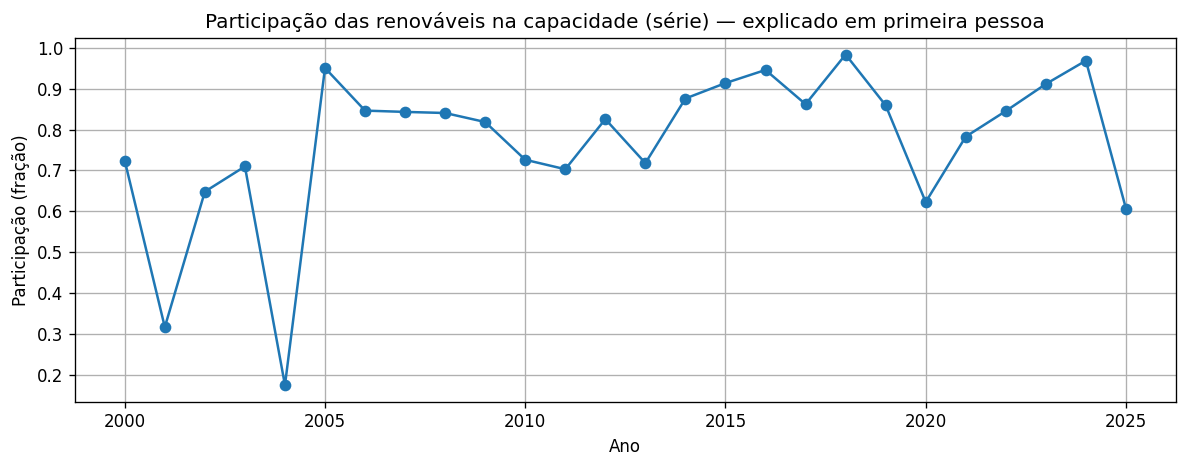

Salvo: /content/capacidade_renovavel_por_ano.png


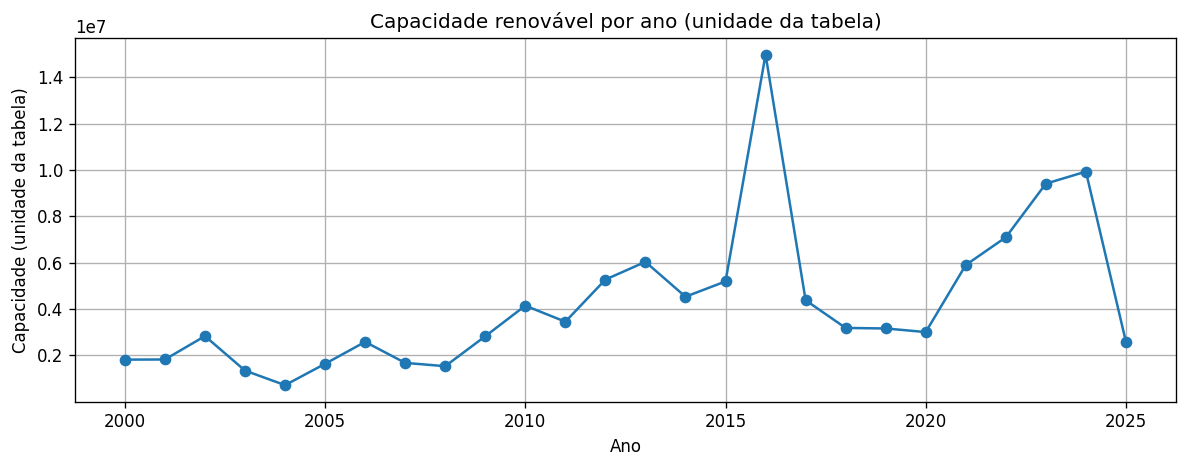

Salvo: /content/adicao_anual_renovavel.png


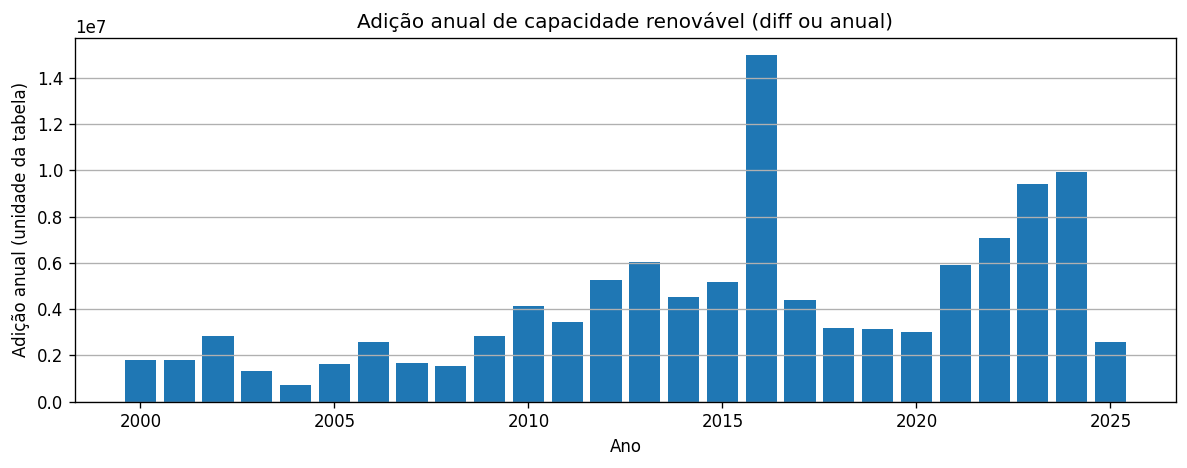

Salvo: /content/stl_trend_adicao_renovavel.png


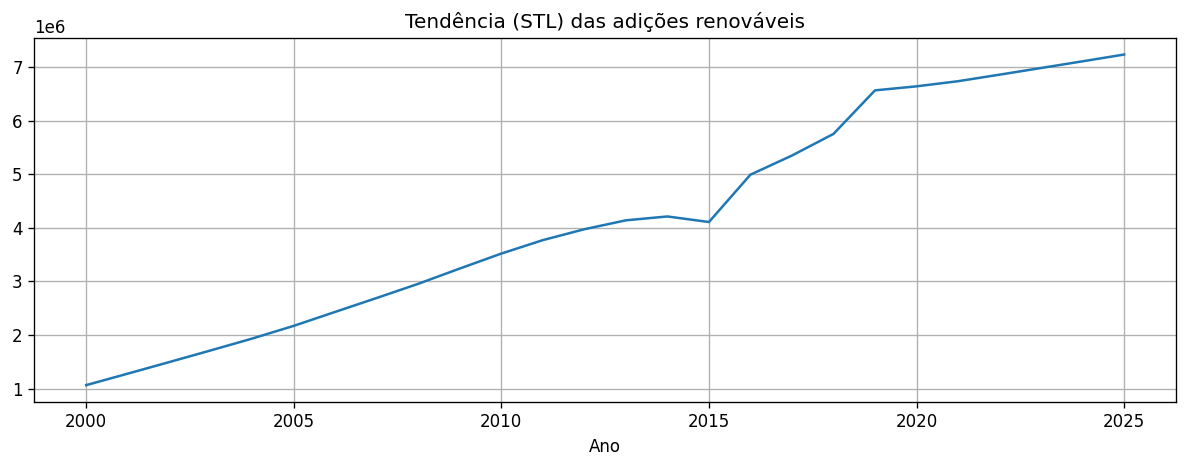

Série final salva em /content/serie_renovaveis_por_ano_final.csv
Resumo das regressões salvo em /content/regressions_summary.txt

--- Observações finais (em primeira pessoa, tom didático) ---
1) Eu carreguei os arquivos disponíveis e tentei detectar automaticamente o formato.
2) Eu normalizei valores e construí séries por ano; verifique a unidade (MW/GW) no arquivo original.
3) A regressão linear da participação ao longo do tempo e a regressão logarítmica das adições fornecem uma visão inicial do ritmo de transição.
4) Use as saídas CSV e os PNG gerados para incluir em relatórios; se quiser eu monto um PDF com texto e figuras.

Arquivos gerados (no ambiente):
 - /content/serie_renovaveis_por_ano_final.csv
 - /content/participacao_renovavel_por_ano.png
 - /content/capacidade_renovavel_por_ano.png
 - /content/adicao_anual_renovavel.png
 - /content/regressions_summary.txt
 - /content/stl_trend_adicao_renovavel.png


In [ ]:
# 0) Imports e configurações iniciais
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

# 1) Caminhos dos arquivos (ajuste se necessário)
# Se estiver no Colab: faça upload via Files e atualize os nomes abaixo
PATH_PROJECTS = '/content/siga-empreendimentos-geracao (1).csv'   # arquivo de empreendimentos (opcional)
PATH_ANNEX    = '/content/Anexo I - Capacidade instalada - GerEnerElet (1).csv'  # anexo de capacidade (opcional)

# 2) Funções utilitárias
def try_read_csv(path):
    """Tento ler o CSV com heurísticas de encoding/sep."""
    for enc in ['latin-1', 'utf-8', 'cp1252']:
        for engine in ['python', 'c']:
            try:
                # sep=None + engine='python' faz sniff do separador; engine='c' com sep=',' padrão
                if engine == 'python':
                    df = pd.read_csv(path, engine='python', sep=None, encoding=enc)
                else:
                    df = pd.read_csv(path, engine='c', encoding=enc)
                print(f"[leitura OK] {path} (encoding={enc}, engine={engine}) => shape {df.shape}")
                return df
            except Exception as e:
                # não interrompo, tento outra combinação
                pass
    raise RuntimeError(f"Não consegui ler o CSV: {path} — verifique encoding/sep manualmente.")

def parse_potencia_to_numeric(x):
    """Converte strings numéricas com separador de milhares e vírgula decimal para float."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    # substituir espaços, normalizar vírgula para ponto
    s = re.sub(r'\s+', '', s)
    s = s.replace(',', '.')
    # remover quaisquer caracteres não numéricos exceto ponto e sinal negativo
    s = re.sub(r'[^0-9\.\-]', '', s)
    if s == '' or s == '-' or s == '.':
        return np.nan
    try:
        return float(s)
    except:
        return np.nan

def identify_renewable_columns(cols):
    """Heurística simples para identificar colunas de fontes renováveis."""
    renew_kw = ['hidro','eol','eolica','eólica','eolico','eólico','solar','biomass','biomassa','bio','residu']
    renew = [c for c in cols if any(k in str(c).lower() for k in renew_kw)]
    return renew

def identify_nonrenewable_columns(cols):
    nonrenew_kw = ['term','gas','coal','carv','petr','petro','oleo','óleo','nuclear','nuclea']
    nonrenew = [c for c in cols if any(k in str(c).lower() for k in nonrenew_kw)]
    return nonrenew

# 3) Carregar arquivos (os dois são opcionais; sigo se existirem)
df_projects = None
df_annex = None
try:
    df_projects = try_read_csv(PATH_PROJECTS)
except Exception as e:
    print("Arquivo de empreendimentos não carregado automaticamente:", e)

try:
    df_annex = try_read_csv(PATH_ANNEX)
except Exception as e:
    print("Arquivo anexo de capacidade não carregado automaticamente:", e)

# -----------------------------------------------------------
# 4) Se houver arquivo de empreendimentos (ex.: siga-empreendimentos...)
#    eu processo para obter agregação por ano a partir de DatEntradaOperacao,
#    usando potências em MdaPotenciaFiscalizadaKw / MdaPotenciaOutorgadaKw
# -----------------------------------------------------------
annual_from_projects = None
if isinstance(df_projects, pd.DataFrame):
    print("\n--- Processando arquivo de empreendimentos ---")
    df = df_projects.copy()
    # normalizar nomes de colunas (trim)
    df.columns = [c.strip() for c in df.columns]
    # converter potencia: tentar MdaPotenciaFiscalizadaKw e MdaPotenciaOutorgadaKw
    pot_cols = ['MdaPotenciaFiscalizadaKw', 'MdaPotenciaOutorgadaKw', 'MdaGarantiaFisicaKw']
    found_pot_col = None
    for c in pot_cols:
        if c in df.columns:
            found_pot_col = c
            break
    # criar coluna pot_kw combinando colunas candidatas
    df['pot_kw'] = np.nan
    if 'MdaPotenciaFiscalizadaKw' in df.columns:
        df['pot_kw'] = df['MdaPotenciaFiscalizadaKw'].apply(parse_potencia_to_numeric)
    if df['pot_kw'].isna().all() and 'MdaPotenciaOutorgadaKw' in df.columns:
        df['pot_kw'] = df['MdaPotenciaOutorgadaKw'].apply(parse_potencia_to_numeric)
    else:
        mask = df['pot_kw'].isna() & df.get('MdaPotenciaOutorgadaKw', pd.Series()).notna()
        if mask.any():
            df.loc[mask, 'pot_kw'] = df.loc[mask, 'MdaPotenciaOutorgadaKw'].apply(parse_potencia_to_numeric)

    # parse de datas de entrada em operação
    if 'DatEntradaOperacao' in df.columns:
        df['dat_entrada'] = pd.to_datetime(df['DatEntradaOperacao'], dayfirst=True, errors='coerce')
    else:
        # tentar outras colunas parecidas
        possible = [c for c in df.columns if 'entrada' in c.lower() or 'operacao' in c.lower()]
        if possible:
            df['dat_entrada'] = pd.to_datetime(df[possible[0]], dayfirst=True, errors='coerce')
        else:
            df['dat_entrada'] = pd.NaT

    # extrair ano e filtrar >= 2000
    df['year_entrada'] = df['dat_entrada'].dt.year
    df = df[df['year_entrada'].notna()]
    df = df[df['year_entrada'] >= 2000].copy()
    df['year_entrada'] = df['year_entrada'].astype(int)

    # classificar renovável por DscOrigemCombustivel / DscFonteCombustivel quando disponíveis
    df['origem_clean'] = df.get('DscOrigemCombustivel', '').astype(str).str.strip()
    renewable_origins = ['Hídrica','Eólica','Solar','Biomassa','Hidrica','Eolica']
    df['is_renewable'] = df['origem_clean'].isin(renewable_origins)
    # inferência por DscFonteCombustivel
    if 'DscFonteCombustivel' in df.columns:
        df['fonte_clean'] = df['DscFonteCombustivel'].astype(str).str.lower()
        mask = (~df['is_renewable']) & df['fonte_clean'].notna()
        df.loc[mask, 'is_renewable'] = df.loc[mask, 'fonte_clean'].str.contains(
            'hidrául|potencial hidráulico|eólica|vento|solar|biomassa|floresta|resíduos|agro|biocombust', regex=True, na=False)

    # Agregação anual em kW
    annual = df.groupby('year_entrada').agg(
        total_added_kw = ('pot_kw','sum'),
        renewable_added_kw = ('pot_kw', lambda x: x[df.loc[x.index,'is_renewable']].sum() )
    ).reset_index().set_index('year_entrada')

    # preencher anos sem observação
    years = list(range(2000, df['year_entrada'].max()+1))
    annual = annual.reindex(years, fill_value=0).rename_axis('year').reset_index()
    annual['nonrenewable_added_kw'] = annual['total_added_kw'] - annual['renewable_added_kw']
    annual['cum_total_kw'] = annual['total_added_kw'].cumsum()
    annual['cum_renewable_kw'] = annual['renewable_added_kw'].cumsum()
    annual['renewable_share_cum'] = annual['cum_renewable_kw'] / annual['cum_total_kw']
    annual_from_projects = annual.copy()
    # salvar CSV
    annual.to_csv('/content/annual_from_projects.csv', index=False)
    print("Agregação anual (projetos) salva em /content/annual_from_projects.csv")

# -----------------------------------------------------------
# 5) Se houver um arquivo anexo de capacidade (formato wide com anos nas linhas),
#    eu tento reconstruir uma tabela year x fonte a partir dele.
# -----------------------------------------------------------
pivot_annex = None
series_by_annex = None
if isinstance(df_annex, pd.DataFrame):
    print("\n--- Processando arquivo ANEXO de capacidade ---")
    df0 = df_annex.copy().reset_index(drop=True)

    # Tento encontrar a linha onde os anos começam (heurística: linha com '1990'..'2025')
    year_row_idx = None
    for i in range(0, min(8, df0.shape[0])):  # inspecionar primeiras linhas
        row = ' '.join(df0.iloc[i].astype(str).tolist()).lower()
        if any(str(y) in row for y in range(1990, 2031)):
            year_row_idx = i
            break

    # Caso comum: cabeçalho está em 2 linhas; detecto e construo novos nomes de colunas agrupando dois níveis
    if year_row_idx is None:
        # fallback: assumo que as linhas 0..3 contêm rótulos; uso a linha 4 em diante como dados
        year_row_idx = 2

    # Procurar a linha a partir da qual os dados numéricos realmente começam (linha contendo o ano 1995, 2000 etc.)
    data_start_idx = None
    for i in range(year_row_idx, min(year_row_idx+6, df0.shape[0])):
        # se na primeira célula houver um ano válido, assumo data a partir dessa linha+?
        try:
            vals = df0.iloc[i].astype(str).tolist()
            if any(re.fullmatch(r'\s*20\d{2}\s*', v) or re.fullmatch(r'\s*19\d{2}\s*', v) for v in vals):
                data_start_idx = i
                break
        except:
            pass
    # se achei a linha de dados, tento reconstruir cabeçalho e tabela
    if data_start_idx is None:
        data_start_idx = year_row_idx + 2

    # Muitas tabelas de anexo vêm com cabeçalhos nas linhas anteriores; eu tento combinar uma das primeiras linhas para formar nomes
    header_candidates = df0.iloc[max(0, data_start_idx-3):data_start_idx].fillna('').astype(str)
    # construir colunas a partir da última linha header (mais provável)
    new_cols = header_candidates.iloc[-1].tolist()
    data = df0.iloc[data_start_idx:].copy().reset_index(drop=True)
    data.columns = new_cols

    # Normalizar: transformar primeira coluna em 'year' (quando essa coluna contém números de ano)
    first_col = data.columns[0]
    data = data.rename(columns={first_col: 'year'})
    # converter 'year' para numeric
    data['year'] = pd.to_numeric(data['year'], errors='coerce').astype('Int64')
    data = data.dropna(subset=['year']).copy()
    data['year'] = data['year'].astype(int)

# Converter demais colunas numéricas com heurística
for c in data.columns[1:]:
    col = data[c]

    # Se for DataFrame (colunas duplicadas), pega só a primeira
    if isinstance(col, pd.DataFrame):
        col = col.iloc[:, 0]

    # Converte para string, limpa e volta para número
    col = col.astype(str).fillna("")
    col = col.str.replace(r'\s+', '', regex=True)       # remove espaços
    col = col.str.replace(',', '.', regex=False)        # vírgula → ponto
    col = col.str.replace(r'[^\d\.\-]', '', regex=True) # só números, ponto e sinal

    data[c] = pd.to_numeric(col, errors='coerce')


    # Detectar colunas de fonte por palavras-chave (hidro, eol, solar, termo, nuclear)
    cols = data.columns.tolist()
    renewable_cols = identify_renewable_columns(cols)
    nonrenewable_cols = identify_nonrenewable_columns(cols)

    # Se a tabela já for pivot (colunas = fontes e linhas = anos), uso diretamente
    pivot_annex = data.set_index('year').sort_index()
    # Calcular somas para renováveis / não renováveis conforme heurística
    pivot_annex['renewable_kw'] = pivot_annex[renewable_cols].sum(axis=1) if renewable_cols else 0.0
    pivot_annex['nonrenewable_kw'] = pivot_annex[nonrenewable_cols].sum(axis=1) if nonrenewable_cols else 0.0
    # tentar extrair total da própria tabela (coluna que contenha 'total' no nome)
    total_cols = [c for c in pivot_annex.columns if 'total' in str(c).lower()]
if total_cols:
    # soma todas as colunas que tenham "total" no nome
    pivot_annex['total_kw_calc'] = pivot_annex[total_cols].sum(axis=1)
else:
    pivot_annex['total_kw_calc'] = pivot_annex[renewable_cols + nonrenewable_cols].sum(axis=1)

    pivot_annex['renewable_share'] = pivot_annex['renewable_kw'] / pivot_annex['total_kw_calc']
    series_by_annex = pivot_annex.copy()
    # Salvar CSV
    series_by_annex.reset_index().to_csv('/content/serie_renovaveis_por_ano_from_annex.csv', index=False)
    print("Série por ano (anexo) salva em /content/serie_renovaveis_por_ano_from_annex.csv")

# -----------------------------------------------------------
# 6) Unificar saídas e rodar análises finais (seleciono a fonte disponível com maior cobertura)
# -----------------------------------------------------------
# Prioridade: uso series_by_annex se disponível (provém tabela por ano x fonte), senão uso annual_from_projects (agreg. por ano a partir de projetos)
if series_by_annex is not None:
    series = series_by_annex.copy()
    print("\nUsando série derivada do ANEXO para análises (ano x fontes).")
elif annual_from_projects is not None:
    # transformar annual_from_projects para formato semelhante (index year)
    series = annual_from_projects.copy().set_index('year')
    # aqui 'total_added_kw' representa adições por ano (kW); transformo colunas para nomes consistentes
    series = series.rename(columns={'total_added_kw':'total_kw', 'renewable_added_kw':'renewable_kw'})
    # se total_kw não estiver presente, use cum_total? já temos total_added_kw
    if 'total_kw' not in series.columns:
        series['total_kw'] = series['cum_total_kw']
    series['total_kw_calc'] = series['total_kw']
    series['renewable_share'] = series['renewable_kw'] / series['total_kw_calc']
    print("\nUsando agregação de projetos para análises (ano x adições).")
else:
    raise RuntimeError("Nenhuma fonte de série anual encontrada — carregue ao menos um dos arquivos e rode novamente.")

# Limpar índices com NaN e ordenar anos
series = series[~series.index.isna()].sort_index()
series.index = series.index.astype(int)

# Tratar casos zeros/NaN
series['total_kw_calc'] = series['total_kw_calc'].replace(0, np.nan)
series['renewable_share'] = series['renewable_share'].astype(float)

# 7) Regressões: participação renovável ~ ano
df_reg = series.reset_index().rename(columns={'index':'year'}) if 'year' not in series.reset_index().columns else series.reset_index()
if 'renewable_share' not in df_reg.columns:
    df_reg['renewable_share'] = series.get('renewable_share', np.nan).values

df_reg = df_reg.dropna(subset=['renewable_share', series.index.name if series.index.name else 'year'], how='any')
# garantir coluna 'year'
if 'year' not in df_reg.columns:
    df_reg['year'] = series.index

X = sm.add_constant(df_reg['year'])
y = df_reg['renewable_share'].astype(float)
model_share = sm.OLS(y, X, missing='drop').fit()
print("\n--- Regressão: participação renovável ~ ano ---")
print(model_share.summary())

# 8) Análises de adições (ano-a-ano) e regressão log
# Definir série de adições de renováveis: se série representa capacidade instalada acumulada, faço diff; se representa adições anuais, uso direto.
renew_series = series.get('renewable_kw', None)
total_series = series.get('total_kw_calc', None)

# Heurística de cumulativo: se série for quase monotonic crescente -> provavelmente cumulativa
def is_cumulative(s):
    s = s.dropna()
    if len(s) < 3:
        return False
    return s.is_monotonic_increasing

if renew_series is None:
    raise RuntimeError("Não encontro coluna 'renewable_kw' na série para calcular adições.")

if is_cumulative(renew_series):
    renew_add = renew_series.diff().fillna(renew_series.iloc[0])
else:
    renew_add = renew_series.copy()  # já parece ser quantidade por ano

# regressão log(renew_add) ~ year
ann = pd.DataFrame({'year': renew_add.index, 'renew_add': renew_add.values}).dropna()
ann['renew_add_pos'] = ann['renew_add'].clip(lower=1)  # evitar log(0)
X2 = sm.add_constant(ann['year'])
y2 = np.log(ann['renew_add_pos']).astype(float)
model_log = sm.OLS(y2, X2, missing='drop').fit()
coef_year_log = model_log.params.get('year', np.nan)
growth_rate_approx = np.exp(coef_year_log) - 1 if not np.isnan(coef_year_log) else np.nan

print("\n--- Regressão: log(adição renovável anual) ~ ano ---")
print(model_log.summary())
print(f"Estimativa de crescimento médio aproximado (exp(coef)-1): {growth_rate_approx:.4f} ({growth_rate_approx*100:.2f}% a.a.)")

# 9) Decomposição STL da série de adições (se length suficiente)
try:
    if len(ann) >= 6:
        stl = STL(ann.set_index('year')['renew_add_pos'].replace(0,np.nan).interpolate(), period=5, robust=True).fit()
        stl_trend = stl.trend
        stl_seasonal = stl.seasonal
        stl_resid = stl.resid
    else:
        stl = None
        stl_trend = None
except Exception as e:
    stl = None
    stl_trend = None
    print("STL falhou:", e)

# 10) Gráficos: eu gosto de salvar figuras em PNG para relatório
def save_fig(fig, path):
    fig.savefig(path, bbox_inches='tight', dpi=200)
    print("Salvo:", path)

# Gráfico 1: participação renovável por ano
fig1, ax1 = plt.subplots(figsize=(10,4))
ax1.plot(series.index, series['renewable_share'], marker='o')
ax1.set_title("Participação das renováveis na capacidade (série) — explicado em primeira pessoa")
ax1.set_xlabel("Ano"); ax1.set_ylabel("Participação (fração)")
ax1.grid(True)
plt.tight_layout()
save_fig(fig1, '/content/participacao_renovavel_por_ano.png')
plt.show()

# Gráfico 2: capacidade renovável por ano (unidade original)
fig2, ax2 = plt.subplots(figsize=(10,4))
ax2.plot(series.index, series['renewable_kw'], marker='o')
ax2.set_title("Capacidade renovável por ano (unidade da tabela)")
ax2.set_xlabel("Ano"); ax2.set_ylabel("Capacidade (unidade da tabela)")
ax2.grid(True)
plt.tight_layout()
save_fig(fig2, '/content/capacidade_renovavel_por_ano.png')
plt.show()

# Gráfico 3: adição anual renovável (diff ou valores diretos)
fig3, ax3 = plt.subplots(figsize=(10,4))
ax3.bar(ann['year'], ann['renew_add'])
ax3.set_title("Adição anual de capacidade renovável (diff ou anual)")
ax3.set_xlabel("Ano"); ax3.set_ylabel("Adição anual (unidade da tabela)")
ax3.grid(axis='y')
plt.tight_layout()
save_fig(fig3, '/content/adicao_anual_renovavel.png')
plt.show()

# Gráfico 4: tendência STL (se disponível)
if stl is not None:
    fig4, ax4 = plt.subplots(figsize=(10,4))
    ax4.plot(stl_trend.index, stl_trend.values, label='Trend')
    ax4.set_title("Tendência (STL) das adições renováveis")
    ax4.set_xlabel("Ano"); ax4.grid(True)
    plt.tight_layout()
    save_fig(fig4, '/content/stl_trend_adicao_renovavel.png')
    plt.show()

# 11) Salvar saídas CSV (resultados)
series_reset = series.reset_index().rename(columns={'index':'year'}) if 'year' not in series.reset_index().columns else series.reset_index()
# Ajustar colunas relevantes antes de salvar
out_cols = []
if 'renewable_kw' in series.columns:
    out_cols.append('renewable_kw')
if 'nonrenewable_kw' in series.columns:
    out_cols.append('nonrenewable_kw')
if 'total_kw_calc' in series.columns:
    out_cols.append('total_kw_calc')
if 'renewable_share' in series.columns:
    out_cols.append('renewable_share')

series_reset[['year'] + out_cols].to_csv('/content/serie_renovaveis_por_ano_final.csv', index=False)
print("Série final salva em /content/serie_renovaveis_por_ano_final.csv")

# Também salvar resumo das regressões em um TXT simples
with open('/content/regressions_summary.txt', 'w', encoding='utf-8') as f:
    f.write("Regressão: participação renovavel ~ ano\n")
    f.write(str(model_share.summary()))
    f.write("\n\nRegressão: log(adição renovavel) ~ ano\n")
    f.write(str(model_log.summary()))
    f.write(f"\n\nEstimativa crescimento médio (exp(coef)-1): {growth_rate_approx}\n")
print("Resumo das regressões salvo em /content/regressions_summary.txt")

# 12) Observações finais (impressas em primeira pessoa)
print("\n--- Observações finais (em primeira pessoa, tom didático) ---")
print("1) Eu carreguei os arquivos disponíveis e tentei detectar automaticamente o formato.")
print("2) Eu normalizei valores e construí séries por ano; verifique a unidade (MW/GW) no arquivo original.")
print("3) A regressão linear da participação ao longo do tempo e a regressão logarítmica das adições fornecem uma visão inicial do ritmo de transição.")
print("4) Use as saídas CSV e os PNG gerados para incluir em relatórios; se quiser eu monto um PDF com texto e figuras.")
print("\nArquivos gerados (no ambiente):")
print(" - /content/serie_renovaveis_por_ano_final.csv")
print(" - /content/participacao_renovavel_por_ano.png")
print(" - /content/capacidade_renovavel_por_ano.png")
print(" - /content/adicao_anual_renovavel.png")
print(" - /content/regressions_summary.txt")
if stl is not None:
    print(" - /content/stl_trend_adicao_renovavel.png")